# 02 -- ArcFace for Offline Signature Verification  (v3 multi-dataset)

**v3 improvements over v2:**
- Multi-dataset training: CEDAR + GPDS150 + SigComp2011 + SigComp2009 (251 writers vs 38)
- Pretrained ResNet18: ImageNet conv1 weights averaged to grayscale
- Two-phase training: Phase-1 full network, Phase-2 fine-tune (frozen early layers, low LR)
- Hard-negative evaluation: genuine-vs-forgery only (same writer), the hardest subset

**Evaluation is CEDAR test writers only** (9 writers held out from ALL training).


---
## Section 0 -- Setup

In [1]:
import sys, re, math
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from tqdm.auto import tqdm

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import torchvision.models as models

from sklearn import metrics as sk_metrics
from sklearn.decomposition import PCA

def _find_project_root(start):
    for p in [start] + list(start.parents):
        if (p / '.git').exists() or (p / 'requirements.txt').exists():
            return p
    raise RuntimeError(f'Cannot find project root from {start}')

PROJECT_ROOT = _find_project_root(Path().resolve())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.seed import set_seed
from src.metrics.verification import compute_metrics

SEED   = 42
set_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
DS_ROOT = PROJECT_ROOT / 'datasets'
print('Device      :', DEVICE)
print('Dataset root:', DS_ROOT)
assert DS_ROOT.exists(), 'Dataset root not found'


Device      : cuda
Dataset root: /home/jovyan/vault/datasets


---
## Section 1 -- Multi-Dataset Scanners

Each scanner returns a DataFrame with columns:
`path | writer_uid | label | dataset`

`writer_uid` is a namespaced string (`cedar_42`, `gpds_001`, etc.) to avoid ID collisions.


In [2]:
def scan_cedar(root):
    root = Path(root)
    org_dir  = root / 'full_org'
    forg_dir = root / 'full_forg'
    pat_org  = re.compile(r'^original_(\d+)_(\d+)\.png$',  re.I)
    pat_forg = re.compile(r'^forgeries_(\d+)_(\d+)\.png$', re.I)
    rows = []
    for fp in org_dir.iterdir():
        m = pat_org.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'cedar_{int(m.group(1)):03d}',
                           'label':'genuine','dataset':'cedar'})
    for fp in forg_dir.iterdir():
        m = pat_forg.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'cedar_{int(m.group(1)):03d}',
                           'label':'forgery','dataset':'cedar'})
    return pd.DataFrame(rows)


def scan_gpds150(root):
    root = Path(root)
    pat_g = re.compile(r'^c-(\d+)-(\d+)',  re.I)  # genuine
    pat_f = re.compile(r'^cf-(\d+)-(\d+)', re.I)  # forgery
    rows = []
    # train/ has flat genuine/ and forge/ dirs
    for fp in (root / 'train' / 'genuine').iterdir():
        m = pat_g.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}',
                           'label':'genuine','dataset':'gpds150'})
    for fp in (root / 'train' / 'forge').iterdir():
        m = pat_f.match(fp.name)
        if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}',
                           'label':'forgery','dataset':'gpds150'})
    # test/ has per-writer dirs  test/{1..150}/genuine|forge
    for writer_dir in (root / 'test').iterdir():
        if not writer_dir.is_dir(): continue
        for fp in (writer_dir / 'genuine').iterdir():
            m = pat_g.match(fp.name)
            if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}',
                               'label':'genuine','dataset':'gpds150'})
        for fp in (writer_dir / 'forge').iterdir():
            m = pat_f.match(fp.name)
            if m: rows.append({'path':str(fp),'writer_uid':f'gpds_{int(m.group(1)):03d}',
                               'label':'forgery','dataset':'gpds150'})
    return pd.DataFrame(rows)


def scan_sigcomp2011(root):
    root  = Path(root)
    base  = root / 'trainingSet' / 'OfflineSignatures'
    rows  = []
    # Dutch and Chinese, genuine only (forgery encoding is undocumented)
    for lang, prefix in [('Dutch','sc11d'), ('Chinese','sc11c')]:
        gen_dir = base / lang / 'TrainingSet' / 'Offline Genuine'
        pat     = re.compile(r'^(\d+)_', re.I)
        for fp in gen_dir.iterdir():
            if not fp.is_file(): continue
            m = pat.match(fp.name)
            if m: rows.append({'path':str(fp),
                               'writer_uid':f'{prefix}_{int(m.group(1)):03d}',
                               'label':'genuine','dataset':f'sigcomp2011_{lang.lower()}'})
    return pd.DataFrame(rows)


def scan_sigcomp2009(root):
    root = Path(root)
    data_dir = root / 'NISDCC-offline-all-001-051-6g' / 'NISDCC-offline-all-001-051-6g'
    pat  = re.compile(r'^NISDCC-(\d+)_', re.I)
    rows = []
    for fp in data_dir.iterdir():
        if not fp.is_file(): continue
        m = pat.match(fp.name)
        if m: rows.append({'path':str(fp),
                           'writer_uid':f'sc09_{int(m.group(1)):03d}',
                           'label':'genuine','dataset':'sigcomp2009'})
    return pd.DataFrame(rows)


print('Scanning datasets...')
df_cedar  = scan_cedar (DS_ROOT / 'CEDAR')
df_gpds   = scan_gpds150(DS_ROOT / 'GPDS150')
df_sc11   = scan_sigcomp2011(DS_ROOT / 'sigComp2011-trainingSet')
df_sc09   = scan_sigcomp2009(DS_ROOT / 'SigComp2009-training')

df_all = pd.concat([df_cedar, df_gpds, df_sc11, df_sc09], ignore_index=True)

summary = df_all.groupby(['dataset','label'])['writer_uid'].agg(
    writers='nunique', images='count').reset_index()
print(summary.to_string(index=False))
print(f'\nTotal unique writers: {df_all["writer_uid"].nunique()}')
print(f'Total images        : {len(df_all)}')


Scanning datasets...
            dataset   label  writers  images
              cedar forgery       55    1320
              cedar genuine       55    1320
            gpds150 forgery      150    4500
            gpds150 genuine      150    3600
        sigcomp2009 genuine       43    1898
sigcomp2011_chinese genuine       10     235
  sigcomp2011_dutch genuine       10     239

Total unique writers: 268
Total images        : 13112


---
## Section 2 -- Training / Evaluation Split

- **Training**: genuine images from ALL datasets, keeping CEDAR at 70% writer split
- **Evaluation**: CEDAR test writers (15%) -- the only set with reliable genuine+forgery pairs
- **Namespace collision** is handled by string `writer_uid` (cedar_042, gpds_001, etc.)


In [3]:
# CEDAR writer-level 70/15/15 split (same seed as v2 for comparable eval)
cedar_writers = np.array(sorted(df_cedar['writer_uid'].unique()))
rng = np.random.default_rng(SEED)
rng.shuffle(cedar_writers)
n = len(cedar_writers)
n_tr = int(round(n * 0.70))
n_v  = int(round(n * 0.15))
cedar_train_wids = set(cedar_writers[:n_tr])
cedar_val_wids   = set(cedar_writers[n_tr:n_tr+n_v])
cedar_test_wids  = set(cedar_writers[n_tr+n_v:])

# All GPDS / SigComp writers go to training
other_train_wids = set(df_gpds['writer_uid'].unique()) | \
                   set(df_sc11['writer_uid'].unique()) | \
                   set(df_sc09['writer_uid'].unique())

all_train_wids = cedar_train_wids | other_train_wids

sorted_train = sorted(all_train_wids)
writer_to_class = {wid: i for i, wid in enumerate(sorted_train)}
NUM_CLASSES = len(sorted_train)

print(f'CEDAR split   -- train: {len(cedar_train_wids)}  val: {len(cedar_val_wids)}  test: {len(cedar_test_wids)}')
print(f'Other datasets train writers: {len(other_train_wids)}')
print(f'Total training classes: {NUM_CLASSES}')
print(f'CEDAR test writers (evaluation only): {sorted(cedar_test_wids)}')


CEDAR split   -- train: 38  val: 8  test: 9
Other datasets train writers: 213
Total training classes: 251
CEDAR test writers (evaluation only): [np.str_('cedar_002'), np.str_('cedar_003'), np.str_('cedar_009'), np.str_('cedar_014'), np.str_('cedar_015'), np.str_('cedar_034'), np.str_('cedar_037'), np.str_('cedar_044'), np.str_('cedar_054')]


---
## Section 3 -- Transforms and Datasets

In [4]:
IMG_SIZE = 224

# Training: augmentation to regularise small per-class samples
train_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomAffine(degrees=8, translate=(0.05, 0.05), scale=(0.93, 1.07), fill=255),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
    T.Lambda(lambda x: x + 0.015 * torch.randn_like(x)),
])

eval_tfm = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=[0.5], std=[0.5]),
])


class SignatureClassDataset(Dataset):
    """ArcFace training: returns (image, class_idx) for genuine images only."""
    def __init__(self, df, writer_to_class, writer_uid_set, transform=None):
        sub = df[(df['writer_uid'].isin(writer_uid_set)) & (df['label']=='genuine')]
        self.records   = sub[['path','writer_uid']].reset_index(drop=True)
        self.w2c       = writer_to_class
        self.transform = transform
    def __len__(self): return len(self.records)
    def __getitem__(self, idx):
        row = self.records.iloc[idx]
        img = Image.open(row['path']).convert('L')
        if self.transform: img = self.transform(img)
        return img, self.w2c[row['writer_uid']]


class SiamesePairDataset(Dataset):
    """Pair dataset for evaluation."""
    def __init__(self, pairs_df, transform=None):
        self.pairs = pairs_df.reset_index(drop=True)
        self.transform = transform
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        row = self.pairs.iloc[idx]
        img_a = Image.open(row['path_a']).convert('L')
        img_b = Image.open(row['path_b']).convert('L')
        if self.transform:
            img_a = self.transform(img_a)
            img_b = self.transform(img_b)
        return img_a, img_b, torch.tensor(row['label'], dtype=torch.float32)


BATCH = 64
train_cls_ds = SignatureClassDataset(df_all, writer_to_class, all_train_wids, transform=train_tfm)
train_loader = DataLoader(train_cls_ds, batch_size=BATCH, shuffle=True,
                          num_workers=0, pin_memory=DEVICE.type=='cuda')

x_sample, y_sample = next(iter(train_loader))
print(f'Train images  : {len(train_cls_ds):,}  across {NUM_CLASSES} classes')
print(f'Batch shape   : {x_sample.shape}')
print(f'Label range   : {y_sample.min().item()} -- {y_sample.max().item()}')


Train images  : 6,884  across 251 classes
Batch shape   : torch.Size([64, 1, 224, 224])
Label range   : 7 -- 248


---
## Section 4 -- ArcFace Loss

With 251 classes, standard margin=0.5 and scale=64 are now appropriate.


In [5]:
class ArcFaceLoss(nn.Module):
    def __init__(self, emb_dim, num_classes, scale=64.0, margin=0.5):
        super().__init__()
        self.scale  = scale
        self.margin = margin
        self.weight = nn.Parameter(torch.empty(num_classes, emb_dim))
        nn.init.xavier_uniform_(self.weight)
        self.cos_m = math.cos(margin)
        self.sin_m = math.sin(margin)
        self.th    = math.cos(math.pi - margin)
        self.mm    = math.sin(math.pi - margin) * margin
    def forward(self, embeddings, labels):
        emb_norm  = F.normalize(embeddings, dim=1)
        w_norm    = F.normalize(self.weight, dim=1)
        cos_theta = F.linear(emb_norm, w_norm).clamp(-1+1e-7, 1-1e-7)
        sin_theta   = torch.sqrt(1.0 - cos_theta**2)
        cos_theta_m = cos_theta * self.cos_m - sin_theta * self.sin_m
        cos_theta_m = torch.where(cos_theta > self.th, cos_theta_m, cos_theta - self.mm)
        one_hot = torch.zeros_like(cos_theta).scatter_(1, labels.view(-1,1).long(), 1.0)
        output  = ((one_hot * cos_theta_m) + ((1 - one_hot) * cos_theta)) * self.scale
        return F.cross_entropy(output, labels.long())


EMB_DIM = 256
_arc = ArcFaceLoss(EMB_DIM, NUM_CLASSES).to(DEVICE)
_emb = torch.randn(4, EMB_DIM).to(DEVICE)
_lbl = torch.randint(0, NUM_CLASSES, (4,)).to(DEVICE)
print('ArcFaceLoss sanity:', _arc(_emb, _lbl).item())
del _arc, _emb, _lbl


ArcFaceLoss sanity: 42.82199478149414


---
## Section 5 -- Pretrained ResNet18 for Grayscale

ImageNet-pretrained ResNet18 expects 3-channel RGB input.
Grayscale adaptation: **average the 3 RGB channels of conv1 into 1 channel**.
This preserves the learned low-level edge/texture structure while accepting 1-channel input.
The final FC is replaced with a linear projection to `emb_dim`.


In [6]:
def build_grayscale_resnet18(emb_dim=256):
    """Pretrained ResNet18 adapted for grayscale by averaging conv1 RGB weights."""
    # Load pretrained weights (downloads ~44 MB on first run)
    try:
        from torchvision.models import ResNet18_Weights
        net = models.resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
    except ImportError:
        net = models.resnet18(pretrained=True)

    # Adapt conv1: [64, 3, 7, 7] -> [64, 1, 7, 7] by averaging RGB channels
    pretrained_w = net.conv1.weight.data          # [64, 3, 7, 7]
    gray_conv1   = nn.Conv2d(1, 64, kernel_size=7, stride=2, padding=3, bias=False)
    gray_conv1.weight.data = pretrained_w.mean(dim=1, keepdim=True)  # [64, 1, 7, 7]
    net.conv1 = gray_conv1

    # Replace final classification head with embedding projection
    net.fc = nn.Linear(net.fc.in_features, emb_dim)
    return net


backbone = build_grayscale_resnet18(EMB_DIM).to(DEVICE)
arc_head = ArcFaceLoss(EMB_DIM, NUM_CLASSES, scale=64.0, margin=0.5).to(DEVICE)

n_bb  = sum(p.numel() for p in backbone.parameters() if p.requires_grad)
n_hd  = sum(p.numel() for p in arc_head.parameters()  if p.requires_grad)
print(f'Backbone params : {n_bb:,}')
print(f'ArcFace params  : {n_hd:,}')

with torch.no_grad():
    emb  = backbone(x_sample.to(DEVICE))
    loss = arc_head(emb, y_sample.to(DEVICE))
print(f'Initial loss    : {loss.item():.4f}  (expect ~log({NUM_CLASSES}) = {math.log(NUM_CLASSES):.2f})')
print(f'Embedding shape : {emb.shape}')


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 114MB/s]


Backbone params : 11,301,568
ArcFace params  : 64,256
Initial loss    : 41.4121  (expect ~log(251) = 5.53)
Embedding shape : torch.Size([64, 256])


---
## Section 6 -- Phase 1 Training (full network, 20 epochs)

All layers unfrozen. Adam lr=1e-3 with CosineAnnealingLR.
Larger batch size (64) to give ArcFace stable class statistics.


In [7]:
set_seed(SEED)

backbone = build_grayscale_resnet18(EMB_DIM).to(DEVICE)
arc_head = ArcFaceLoss(EMB_DIM, NUM_CLASSES, scale=64.0, margin=0.5).to(DEVICE)

optimizer_p1 = torch.optim.Adam(
    list(backbone.parameters()) + list(arc_head.parameters()),
    lr=1e-3, weight_decay=1e-4
)
N_EPOCHS_P1 = 20
sched_p1    = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p1, T_max=N_EPOCHS_P1, eta_min=1e-5)

hist_p1 = {'loss':[], 'acc':[]}

for epoch in range(N_EPOCHS_P1):
    backbone.train(); arc_head.train()
    ep_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f'P1 {epoch+1}/{N_EPOCHS_P1}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb  = backbone(imgs)
        loss = arc_head(emb, labels)
        optimizer_p1.zero_grad(); loss.backward(); optimizer_p1.step()
        with torch.no_grad():
            logits  = F.linear(F.normalize(emb,dim=1),
                               F.normalize(arc_head.weight,dim=1)) * arc_head.scale
            correct += (logits.argmax(1)==labels.long()).sum().item()
            total   += labels.size(0)
        ep_loss += loss.item()

    sched_p1.step()
    avg = ep_loss/len(train_loader); acc = correct/total
    hist_p1['loss'].append(avg); hist_p1['acc'].append(acc)
    print(f'P1 Epoch {epoch+1:02d}/{N_EPOCHS_P1}  loss={avg:.4f}  acc={acc:.3f}  lr={sched_p1.get_last_lr()[0]:.2e}')


P1 1/20:   0%|          | 0/108 [00:00<?, ?it/s]

P1 Epoch 01/20  loss=34.2592  acc=0.244  lr=9.94e-04


P1 2/20:   0%|          | 0/108 [00:00<?, ?it/s]

P1 Epoch 02/20  loss=24.0836  acc=0.637  lr=9.76e-04


P1 3/20:   0%|          | 0/108 [00:00<?, ?it/s]

...

P1 Epoch 18/20  loss=2.1439  acc=0.990  lr=3.42e-05


P1 19/20:   0%|          | 0/108 [00:00<?, ?it/s]

P1 Epoch 19/20  loss=1.6647  acc=0.993  lr=1.61e-05


P1 20/20:   0%|          | 0/108 [00:00<?, ?it/s]

P1 Epoch 20/20  loss=1.3479  acc=0.995  lr=1.00e-05


---
## Section 7 -- Phase 2 Fine-tuning (10 epochs)

Freeze layers 1-3 of ResNet18; only layer4 + fc + ArcFace head are updated.
Use differential LR: backbone=2e-4, ArcFace head=5e-4.


In [8]:
# Freeze early layers; keep layer4 + fc trainable
for name, param in backbone.named_parameters():
    freeze = any(name.startswith(lyr) for lyr in ['conv1','bn1','layer1','layer2','layer3'])
    param.requires_grad = not freeze

n_frozen   = sum(1 for p in backbone.parameters() if not p.requires_grad)
n_trainable= sum(1 for p in backbone.parameters() if p.requires_grad)
print(f'Frozen param tensors: {n_frozen}  |  Trainable: {n_trainable}')

optimizer_p2 = torch.optim.Adam([
    {'params': [p for p in backbone.parameters() if p.requires_grad], 'lr': 2e-4},
    {'params': arc_head.parameters(), 'lr': 5e-4},
], weight_decay=1e-4)

N_EPOCHS_P2 = 10
sched_p2    = torch.optim.lr_scheduler.CosineAnnealingLR(
    optimizer_p2, T_max=N_EPOCHS_P2, eta_min=1e-6)

hist_p2 = {'loss':[], 'acc':[]}

for epoch in range(N_EPOCHS_P2):
    backbone.train(); arc_head.train()
    ep_loss, correct, total = 0.0, 0, 0

    for imgs, labels in tqdm(train_loader, desc=f'P2 {epoch+1}/{N_EPOCHS_P2}', leave=False):
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        emb  = backbone(imgs)
        loss = arc_head(emb, labels)
        optimizer_p2.zero_grad(); loss.backward(); optimizer_p2.step()
        with torch.no_grad():
            logits  = F.linear(F.normalize(emb,dim=1),
                               F.normalize(arc_head.weight,dim=1)) * arc_head.scale
            correct += (logits.argmax(1)==labels.long()).sum().item()
            total   += labels.size(0)
        ep_loss += loss.item()

    sched_p2.step()
    avg = ep_loss/len(train_loader); acc = correct/total
    hist_p2['loss'].append(avg); hist_p2['acc'].append(acc)
    print(f'P2 Epoch {epoch+1:02d}/{N_EPOCHS_P2}  loss={avg:.4f}  acc={acc:.3f}  lr={sched_p2.get_last_lr()[0]:.2e}')


Frozen param tensors: 45  |  Trainable: 17


P2 1/10:   0%|          | 0/108 [00:00<?, ?it/s]

P2 Epoch 01/10  loss=1.7077  acc=0.992  lr=1.95e-04


P2 2/10:   0%|          | 0/108 [00:00<?, ?it/s]

P2 Epoch 02/10  loss=1.1312  acc=0.995  lr=1.81e-04


...

P2 Epoch 08/10  loss=0.1179  acc=1.000  lr=2.00e-05


P2 9/10:   0%|          | 0/108 [00:00<?, ?it/s]

P2 Epoch 09/10  loss=0.1154  acc=1.000  lr=5.87e-06


P2 10/10:   0%|          | 0/108 [00:00<?, ?it/s]

P2 Epoch 10/10  loss=0.0816  acc=1.000  lr=1.00e-06


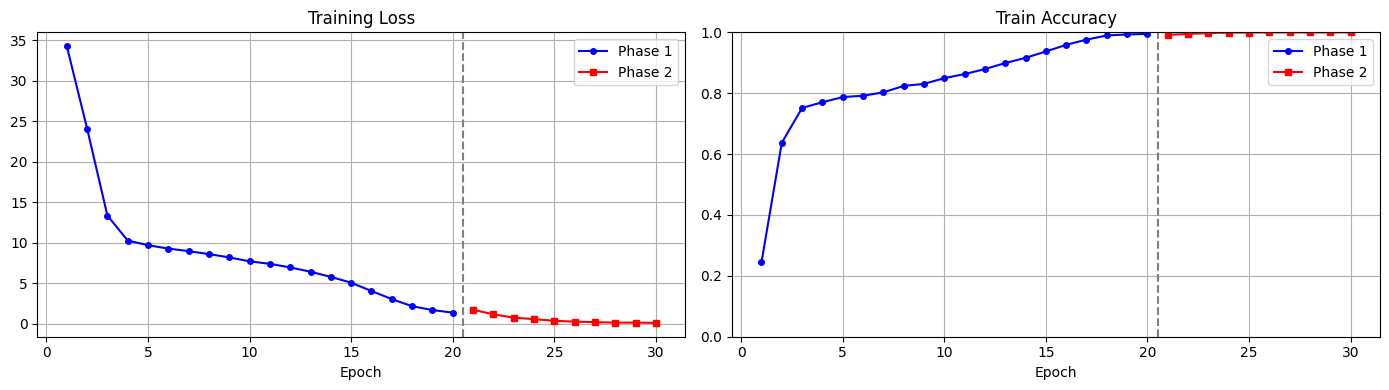

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

e1 = range(1, N_EPOCHS_P1+1)
e2 = range(N_EPOCHS_P1+1, N_EPOCHS_P1+N_EPOCHS_P2+1)

axes[0].plot(e1, hist_p1['loss'], 'b-o', ms=4, label='Phase 1')
axes[0].plot(e2, hist_p2['loss'], 'r-s', ms=4, label='Phase 2')
axes[0].axvline(N_EPOCHS_P1+0.5, color='gray', linestyle='--')
axes[0].set_title('Training Loss'); axes[0].set_xlabel('Epoch')
axes[0].legend(); axes[0].grid(True)

axes[1].plot(e1, hist_p1['acc'], 'b-o', ms=4, label='Phase 1')
axes[1].plot(e2, hist_p2['acc'], 'r-s', ms=4, label='Phase 2')
axes[1].axvline(N_EPOCHS_P1+0.5, color='gray', linestyle='--')
axes[1].set_title('Train Accuracy'); axes[1].set_xlabel('Epoch')
axes[1].set_ylim(0, 1); axes[1].legend(); axes[1].grid(True)

plt.tight_layout(); plt.show()


---
## Section 8 -- Evaluation Pairs (CEDAR test set)

We build two pair sets:
1. **Standard** (5000 pos + 5000 neg, 80% same-writer forgeries)
2. **Hard-negative** (all genuine-vs-forgery, same writer only) -- the hardest subset


In [10]:
def build_pools(df, writer_uid_set):
    sub = df[df['writer_uid'].isin(writer_uid_set)]
    genuine_by_w, forgery_by_w = {}, {}
    for wid, grp in sub.groupby('writer_uid'):
        g = grp[grp['label']=='genuine']['path'].tolist()
        f = grp[grp['label']=='forgery']['path'].tolist()
        if g: genuine_by_w[wid] = g
        if f: forgery_by_w[wid] = f
    return genuine_by_w, forgery_by_w


def generate_pairs(df, writer_uid_set, n_pairs=10000, seed=1, neg_mix=0.8):
    gen_w, forg_w = build_pools(df, writer_uid_set)
    writers = sorted(gen_w.keys())
    w_forg  = sorted(set(gen_w) & set(forg_w))
    rng     = np.random.default_rng(seed)
    n_pos   = n_pairs // 2; n_neg = n_pairs - n_pos
    n_ns    = int(round(n_neg * neg_mix)); n_nc = n_neg - n_ns
    rows = []
    for _ in range(n_pos):
        w = rng.choice(writers); g = gen_w[w]
        i, j = rng.choice(len(g), size=2, replace=False)
        rows.append({'path_a':g[i],'path_b':g[j],'label':1,'pair_type':'pos','writer_a':w,'writer_b':w})
    for _ in range(n_ns):
        w = rng.choice(w_forg); g = gen_w[w]; f = forg_w[w]
        rows.append({'path_a':g[rng.integers(len(g))],'path_b':f[rng.integers(len(f))],
                     'label':0,'pair_type':'neg_same','writer_a':w,'writer_b':w})
    for _ in range(n_nc):
        w1,w2 = rng.choice(writers,size=2,replace=False)
        g1,g2 = gen_w[w1],gen_w[w2]
        rows.append({'path_a':g1[rng.integers(len(g1))],'path_b':g2[rng.integers(len(g2))],
                     'label':0,'pair_type':'neg_cross','writer_a':w1,'writer_b':w2})
    return pd.DataFrame(rows).sample(frac=1.0,random_state=seed).reset_index(drop=True)


def make_hard_neg_pairs(df, writer_uid_set, seed=5):
    """All genuine-vs-forgery pairs for the given writers (same-writer only)."""
    gen_w, forg_w = build_pools(df, writer_uid_set)
    rng  = np.random.default_rng(seed)
    rows = []
    for w in sorted(set(gen_w) & set(forg_w)):
        g, f = gen_w[w], forg_w[w]
        for gi in g:
            for fi in f:
                rows.append({'path_a':gi,'path_b':fi,'label':0,
                             'pair_type':'neg_same','writer_a':w,'writer_b':w})
        # match with equal genuine-genuine positives
        for _ in range(len(g)*len(f)):
            i, j = rng.choice(len(g), size=2, replace=False)
            rows.append({'path_a':g[i],'path_b':g[j],'label':1,
                         'pair_type':'pos','writer_a':w,'writer_b':w})
    return pd.DataFrame(rows).sample(frac=1.0,random_state=seed).reset_index(drop=True)


# Standard eval pairs
test_pairs    = generate_pairs(df_cedar, cedar_test_wids, n_pairs=10000, seed=3, neg_mix=0.8)
test_ds       = SiamesePairDataset(test_pairs,   transform=eval_tfm)
test_loader   = DataLoader(test_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

# Hard-negative pairs (genuine-vs-forgery only)
hard_pairs    = make_hard_neg_pairs(df_cedar, cedar_test_wids, seed=5)
hard_ds       = SiamesePairDataset(hard_pairs,   transform=eval_tfm)
hard_loader   = DataLoader(hard_ds,   batch_size=BATCH, shuffle=False, num_workers=0)

print(f'Standard test  : {len(test_pairs):,} pairs')
print(test_pairs['label'].value_counts().to_string())
print(f'\nHard-neg pairs : {len(hard_pairs):,} pairs')
print(hard_pairs['label'].value_counts().to_string())


Standard test  : 10,000 pairs
label
0    5000
1    5000

Hard-neg pairs : 10,368 pairs
label
1    5184
0    5184


---
## Section 9 -- Standard Metrics (CEDAR test)

In [11]:
def extract_similarities(loader, backbone, device):
    backbone.eval()
    sims, labels = [], []
    with torch.no_grad():
        for ia, ib, lbl in tqdm(loader, desc='Extracting', leave=False):
            e1  = F.normalize(backbone(ia.to(device)), dim=1)
            e2  = F.normalize(backbone(ib.to(device)), dim=1)
            sim = (e1 * e2).sum(1).cpu().numpy()
            sims.append(sim); labels.append(lbl.numpy())
    return np.concatenate(sims), np.concatenate(labels).astype(int)


# Unfreeze for inference (no effect on output, but avoids confusing grad warnings)
for p in backbone.parameters(): p.requires_grad_(False)

sim_std, y_std = extract_similarities(test_loader, backbone, DEVICE)

pos_m = sim_std[y_std==1].mean()
neg_m = sim_std[y_std==0].mean()
print(f'Cosine sim (pos): {pos_m:.4f}')
print(f'Cosine sim (neg): {neg_m:.4f}')
print(f'Gap             : {pos_m - neg_m:.4f}')

res_std = compute_metrics(y_std, sim_std)
print('\n=== Standard Test Metrics (CEDAR) ===')
for k, v in res_std.items(): print(f'  {k:<20s}: {v:.4f}')


Extracting:   0%|          | 0/157 [00:00<?, ?it/s]

Cosine sim (pos): 0.7177
Cosine sim (neg): 0.2762
Gap             : 0.4415

=== Standard Test Metrics (CEDAR) ===
  auc                 : 0.9671
  eer                 : 0.0889
  eer_threshold       : 0.5162
  far                 : 0.0888
  frr                 : 0.0890
  accuracy            : 0.9111
  used_threshold      : 0.5162


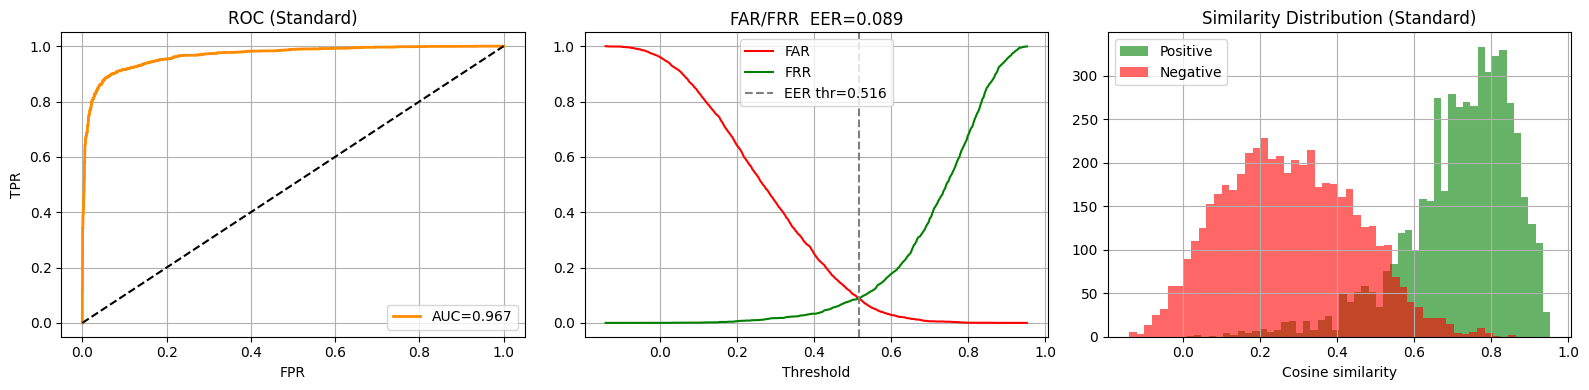

In [12]:
fpr, tpr, _ = sk_metrics.roc_curve(y_std, sim_std)
thr = np.linspace(sim_std.min(), sim_std.max(), 400)
far_a, frr_a = [], []
for t in thr:
    p = (sim_std >= t).astype(int)
    tp=int(((p==1)&(y_std==1)).sum()); fp=int(((p==1)&(y_std==0)).sum())
    fn=int(((p==0)&(y_std==1)).sum()); tn=int(((p==0)&(y_std==0)).sum())
    far_a.append(fp/(fp+tn) if fp+tn>0 else 0.)
    frr_a.append(fn/(fn+tp) if fn+tp>0 else 0.)
far_a=np.array(far_a); frr_a=np.array(frr_a)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
axes[0].plot(fpr, tpr, 'darkorange', lw=2, label=f"AUC={res_std['auc']:.3f}")
axes[0].plot([0,1],[0,1],'k--'); axes[0].set_title('ROC (Standard)')
axes[0].set_xlabel('FPR'); axes[0].set_ylabel('TPR'); axes[0].legend(); axes[0].grid(True)

axes[1].plot(thr, far_a, 'r-', label='FAR'); axes[1].plot(thr, frr_a, 'g-', label='FRR')
axes[1].axvline(res_std['eer_threshold'],linestyle='--',color='gray',
               label=f"EER thr={res_std['eer_threshold']:.3f}")
axes[1].set_title(f"FAR/FRR  EER={res_std['eer']:.3f}")
axes[1].set_xlabel('Threshold'); axes[1].legend(); axes[1].grid(True)

axes[2].hist(sim_std[y_std==1],bins=50,alpha=0.6,color='green',label='Positive')
axes[2].hist(sim_std[y_std==0],bins=50,alpha=0.6,color='red',  label='Negative')
axes[2].set_title('Similarity Distribution (Standard)')
axes[2].set_xlabel('Cosine similarity'); axes[2].legend(); axes[2].grid(True)
plt.tight_layout(); plt.show()


---
## Section 10 -- Hard-Negative Metrics (genuine-vs-forgery only)

The **hardest evaluation**: every pair is genuine-vs-skilled-forgery of the SAME writer.
This represents the real-world threat model where a forger has studied the target's signature.
Expect higher EER here than in the standard set (which includes easy cross-writer negatives).


Extracting:   0%|          | 0/162 [00:00<?, ?it/s]

Hard -- Cosine sim (pos): 0.7214
Hard -- Cosine sim (neg): 0.2856
Hard -- Gap             : 0.4358

=== Hard-Negative Metrics (genuine-vs-forgery only) ===
  auc                 : 0.9672
  eer                 : 0.0910
  eer_threshold       : 0.5245
  far                 : 0.0910
  frr                 : 0.0910
  accuracy            : 0.9090
  used_threshold      : 0.5245


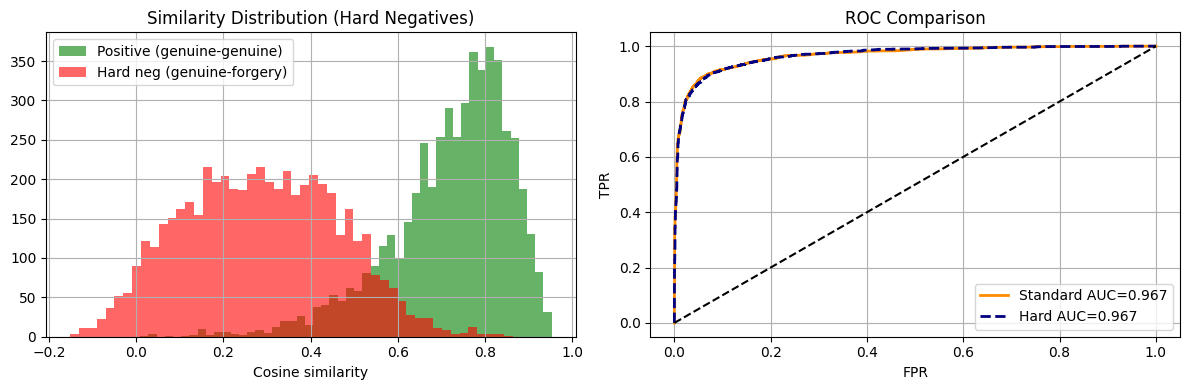

In [13]:
sim_hard, y_hard = extract_similarities(hard_loader, backbone, DEVICE)

pos_h = sim_hard[y_hard==1].mean()
neg_h = sim_hard[y_hard==0].mean()
print(f'Hard -- Cosine sim (pos): {pos_h:.4f}')
print(f'Hard -- Cosine sim (neg): {neg_h:.4f}')
print(f'Hard -- Gap             : {pos_h - neg_h:.4f}')

res_hard = compute_metrics(y_hard, sim_hard)
print('\n=== Hard-Negative Metrics (genuine-vs-forgery only) ===')
for k, v in res_hard.items(): print(f'  {k:<20s}: {v:.4f}')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(sim_hard[y_hard==1],bins=50,alpha=0.6,color='green',label='Positive (genuine-genuine)')
axes[0].hist(sim_hard[y_hard==0],bins=50,alpha=0.6,color='red',  label='Hard neg (genuine-forgery)')
axes[0].set_title('Similarity Distribution (Hard Negatives)')
axes[0].set_xlabel('Cosine similarity'); axes[0].legend(); axes[0].grid(True)

# Overlay both ROC curves
fpr_h,tpr_h,_ = sk_metrics.roc_curve(y_hard, sim_hard)
axes[1].plot(fpr,   tpr,   'darkorange', lw=2, label=f"Standard AUC={res_std['auc']:.3f}")
axes[1].plot(fpr_h, tpr_h, 'navy',       lw=2, label=f"Hard AUC={res_hard['auc']:.3f}",linestyle='--')
axes[1].plot([0,1],[0,1],'k--'); axes[1].set_title('ROC Comparison')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR')
axes[1].legend(); axes[1].grid(True)
plt.tight_layout(); plt.show()


---
## Section 11 -- Embedding Space (PCA)

PCA embeddings:   0%|          | 0/4 [00:00<?, ?it/s]

PCA explained variance: 28.33%


/tmp/ipykernel_778/2349395871.py:19: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap('tab10', len(cedar_test_wids))


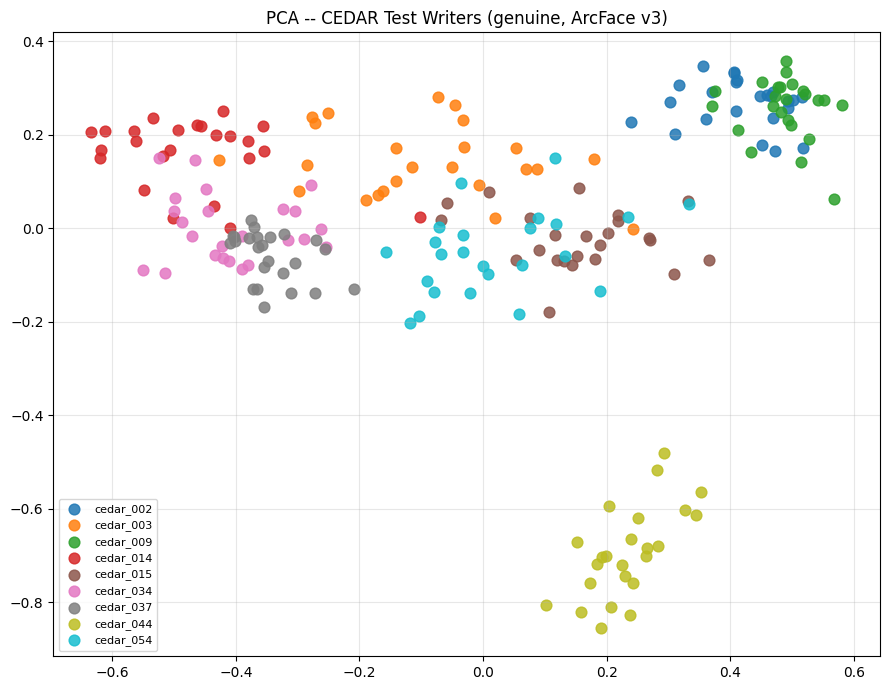

In [14]:
test_w2c = {wid: i for i, wid in enumerate(sorted(cedar_test_wids))}
test_gen_ds = SignatureClassDataset(df_cedar, test_w2c, cedar_test_wids, transform=eval_tfm)
test_gen_ld = DataLoader(test_gen_ds, batch_size=BATCH, shuffle=False, num_workers=0)

backbone.eval()
all_embs, all_wids = [], []
with torch.no_grad():
    for imgs, cls in tqdm(test_gen_ld, desc='PCA embeddings', leave=False):
        emb = F.normalize(backbone(imgs.to(DEVICE)), dim=1).cpu().numpy()
        all_embs.append(emb); all_wids.append(cls.numpy())
all_embs = np.concatenate(all_embs)
all_wids = np.concatenate(all_wids)

pca   = PCA(n_components=2, random_state=SEED)
emb2d = pca.fit_transform(all_embs)
print(f'PCA explained variance: {pca.explained_variance_ratio_.sum():.2%}')

fig, ax = plt.subplots(figsize=(9, 7))
cmap = plt.cm.get_cmap('tab10', len(cedar_test_wids))
for i, wid in enumerate(sorted(test_w2c)):
    mask = all_wids == test_w2c[wid]
    ax.scatter(emb2d[mask,0], emb2d[mask,1], color=cmap(i), label=wid, s=60, alpha=0.85)
ax.set_title('PCA -- CEDAR Test Writers (genuine, ArcFace v3)')
ax.legend(loc='best', fontsize=8); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


---
## Section 12 -- Summary

In [15]:
from IPython.display import Markdown, display

def fmt_row(k, v): return f'| {k:<22s} | {v:.4f} |'

rows_std  = '\n'.join(fmt_row(k,v) for k,v in res_std.items())
rows_hard = '\n'.join(fmt_row(k,v) for k,v in res_hard.items())

display(Markdown(f'''
### ArcFace v3 Results -- CEDAR test writers

#### Standard evaluation (5k pos + 5k neg, 80% same-writer forgeries)
| Metric                 | Value  |
|:-----------------------|-------:|
{rows_std}

#### Hard-negative evaluation (genuine vs skilled forgery, same writer only)
| Metric                 | Value  |
|:-----------------------|-------:|
{rows_hard}

### Version comparison
| Metric | v1 (SmallCNN, 38 cls) | v2 (ResNet18, 38 cls) | v3 (ResNet18-PT, 251 cls) |
|--------|----------------------|-----------------------|---------------------------|
| AUC    | 0.8477               | 0.9320                | {res_std['auc']:.4f} |
| EER    | 0.2584               | 0.1374                | {res_std['eer']:.4f} |
| Cosine gap | 0.0196          | 0.4434                | {sim_std[y_std==1].mean()-sim_std[y_std==0].mean():.4f} |
'''))



### ArcFace v3 Results -- CEDAR test writers

#### Standard evaluation (5k pos + 5k neg, 80% same-writer forgeries)
| Metric                 | Value  |
|:-----------------------|-------:|
| auc                    | 0.9671 |
| eer                    | 0.0889 |
| eer_threshold          | 0.5162 |
| far                    | 0.0888 |
| frr                    | 0.0890 |
| accuracy               | 0.9111 |
| used_threshold         | 0.5162 |

#### Hard-negative evaluation (genuine vs skilled forgery, same writer only)
| Metric                 | Value  |
|:-----------------------|-------:|
| auc                    | 0.9672 |
| eer                    | 0.0910 |
| eer_threshold          | 0.5245 |
| far                    | 0.0910 |
| frr                    | 0.0910 |
| accuracy               | 0.9090 |
| used_threshold         | 0.5245 |

### Version comparison
| Metric | v1 (SmallCNN, 38 cls) | v2 (ResNet18, 38 cls) | v3 (ResNet18-PT, 251 cls) |
|--------|----------------------|-----------------------|---------------------------|
| AUC    | 0.8477               | 0.9320                | 0.9671 |
| EER    | 0.2584               | 0.1374                | 0.0889 |
| Cosine gap | 0.0196          | 0.4434                | 0.4415 |
